# Explainable Multiclass Transformed AneRBC-II VGG16

This notebook runs inference-only explainability for a trained VGG16-based multiclass model.

It implements:

- Grad-CAM for the image input branch.
- SHAP for the CBC/tabular input branch when the loaded model has a CBC input.

The notebook loads the trained VGG16 fusion model directly from `kaggle_vgg16_transformed_AneRBC_II_multiClass_fusion_model_artifacts/` (the `.keras` file under `models/`). It never retrains the model.

## 1. Environment And Imports

This setup keeps the notebook inference-only. Local Apple Silicon runs default to CPU for stability unless `ANERBC_USE_LOCAL_METAL=1` is set before starting the kernel.

In [8]:
import os
from pathlib import Path


def detect_env() -> str:
    if Path("/kaggle/input").exists():
        return "kaggle"
    try:
        import google.colab  # noqa: F401
        return "colab"
    except ImportError:
        return "local"


ENV = detect_env()
LOCAL_METAL_GPU_OPT_IN = os.environ.get("ANERBC_USE_LOCAL_METAL", "0") == "1"
if ENV == "local" and not LOCAL_METAL_GPU_OPT_IN:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")

print(f"Detected environment: {ENV}")

Detected environment: local


In [9]:
import importlib
import json
import random
import subprocess
import sys
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import tensorflow as tf

if ENV == "local" and not LOCAL_METAL_GPU_OPT_IN:
    try:
        tf.config.set_visible_devices([], "GPU")
        print("Local TensorFlow GPU disabled. Set ANERBC_USE_LOCAL_METAL=1 before kernel start to opt in.")
    except RuntimeError as exc:
        print(f"Could not hide local GPU because TensorFlow was already initialized: {exc}")


def import_or_install(package_name: str, pip_name: str | None = None):
    try:
        return importlib.import_module(package_name)
    except ImportError:
        install_name = pip_name or package_name
        print(f"{package_name} is not installed. Installing {install_name} in this kernel...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", install_name])
        return importlib.import_module(package_name)


try:
    shap = import_or_install("shap")
    SHAP_AVAILABLE = True
except Exception as exc:
    shap = None
    SHAP_AVAILABLE = False
    print(f"SHAP is unavailable, so CBC SHAP cells will be skipped: {exc}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Visible GPUs:", tf.config.get_visible_devices("GPU"))
print("SHAP available:", SHAP_AVAILABLE)

Local TensorFlow GPU disabled. Set ANERBC_USE_LOCAL_METAL=1 before kernel start to opt in.
TensorFlow version: 2.18.1
Visible GPUs: []
SHAP available: True


## 2. Constants And Paths

These constants mirror the training notebook preprocessing: raw RGB images are resized to `224x224` and the saved model contains the VGG16 BGR mean-subtraction preprocessing layer. CBC values use the same feature order and train-median imputation used during training.

The trained model is loaded from the local artifacts folder `kaggle_vgg16_transformed_AneRBC_II_multiClass_fusion_model_artifacts/`.

In [10]:
KAGGLE_DATASET_ID = "n07kiran/transformed-AneRBC-dataset"
KAGGLE_DATASET_SLUGS = (
    "transformed-anerbc-dataset",
    "transformed-AneRBC-dataset",
)
TRANSFORMED_DATASET_DIRNAME = "transformed_AneRBC_dataset"
TRANSFORMED_SUBSET_NAME = "transformed_AneRBC-II"
TRANSFORMED_SUBSET_SLUG = "transformed_aneRBC_ii"

MODEL_SLUG = "vgg16"
MODEL_DISPLAY_NAME = "VGG16"
BASE_LAYER_NAME = "vgg16"
IMAGE_SIZE = (224, 224)
PREPROCESS_MODE = "vgg16_caffe"

CLASS_ID_TO_NAME = {
    0: "Healthy",
    1: "Microcytic",
    2: "Normocytic",
    3: "Macrocytic",
}
CLASS_NAMES = [CLASS_ID_TO_NAME[i] for i in sorted(CLASS_ID_TO_NAME)]
NUM_CLASSES = len(CLASS_NAMES)

CBC_FEATURES = ["WBC", "RBC", "HGB", "HCT", "MCV", "MCH", "MCHC", "PLT", "MPV", "RDW_CV"]

ARTIFACTS_DIRNAME = "kaggle_vgg16_transformed_AneRBC_II_multiClass_fusion_model_artifacts"
EXPECTED_MODEL_FILENAME = "multiClass_transformed_aneRBC_ii_vgg16_fusion_best.keras"


def parent_candidates(start: Path):
    current = start.resolve()
    yield current
    for parent in current.parents:
        yield parent


def find_repo_root() -> Path:
    override = os.environ.get("ANERBC_REPO_ROOT")
    if override:
        root = Path(override).expanduser().resolve()
        if root.exists():
            return root
        raise FileNotFoundError(f"ANERBC_REPO_ROOT does not exist: {root}")

    for candidate in parent_candidates(Path.cwd()):
        if (candidate / "Code" / "newFusionModel").exists() or (candidate / TRANSFORMED_DATASET_DIRNAME).exists():
            return candidate

    colab_root = Path("/content/drive/MyDrive/Anemia FYP")
    if ENV == "colab" and colab_root.exists():
        return colab_root

    return Path.cwd().resolve()


def get_output_root(repo_root: Path) -> Path:
    override = os.environ.get("ANERBC_OUTPUT_ROOT")
    if override:
        return Path(override).expanduser().resolve()
    if ENV == "kaggle":
        return Path("/kaggle/working")
    return repo_root


REPO_ROOT = find_repo_root()
OUTPUT_ROOT = get_output_root(REPO_ROOT)

MODEL_ARTIFACTS_ROOT = REPO_ROOT / ARTIFACTS_DIRNAME
EXPECTED_MODEL_PATH = MODEL_ARTIFACTS_ROOT / "models" / EXPECTED_MODEL_FILENAME

EXPLANATION_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "Code"
    / "newFusionModel"
    / "multiClassImageClassification"
    / "artifacts"
    / TRANSFORMED_SUBSET_SLUG
    / "explainability"
    / MODEL_SLUG
)
EXPLANATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("MODEL_ARTIFACTS_ROOT:", MODEL_ARTIFACTS_ROOT)
print("EXPECTED_MODEL_PATH:", EXPECTED_MODEL_PATH)
print("EXPLANATION_OUTPUT_DIR:", EXPLANATION_OUTPUT_DIR)

REPO_ROOT: /Users/kiran/Downloads/fyp
OUTPUT_ROOT: /Users/kiran/Downloads/fyp
MODEL_ARTIFACTS_ROOT: /Users/kiran/Downloads/fyp/kaggle_vgg16_transformed_AneRBC_II_multiClass_fusion_model_artifacts
EXPECTED_MODEL_PATH: /Users/kiran/Downloads/fyp/kaggle_vgg16_transformed_AneRBC_II_multiClass_fusion_model_artifacts/models/multiClass_transformed_aneRBC_ii_vgg16_fusion_best.keras
EXPLANATION_OUTPUT_DIR: /Users/kiran/Downloads/fyp/Code/newFusionModel/multiClassImageClassification/artifacts/transformed_aneRBC_ii/explainability/vgg16


## 3. Custom Layer Registration

The trained fusion model serializes a small preprocessing layer. Registering the same class allows Keras to load the saved `.keras` artifact without retraining.

In [11]:
@tf.keras.utils.register_keras_serializable(package="newFusionModel")
class BackbonePreprocessing(tf.keras.layers.Layer):
    """Backbone preprocessing layer for raw RGB images in the 0..255 range."""

    def __init__(self, mode: str, **kwargs):
        super().__init__(**kwargs)
        if mode not in {"vgg16_caffe", "tf_minus_one_to_one", "unit_range"}:
            raise ValueError(f"Unsupported preprocess mode: {mode}")
        self.mode = mode

    def call(self, images):
        images = tf.cast(images, tf.float32)

        if self.mode == "vgg16_caffe":
            bgr = tf.reverse(images, axis=[-1])
            imagenet_bgr_mean = tf.constant([103.939, 116.779, 123.68], dtype=tf.float32)
            return bgr - imagenet_bgr_mean

        if self.mode == "unit_range":
            return images / 255.0

        return (images / 127.5) - 1.0

    def get_config(self):
        config = super().get_config()
        config.update({"mode": self.mode})
        return config


CUSTOM_OBJECTS = {
    "BackbonePreprocessing": BackbonePreprocessing,
    "newFusionModel>BackbonePreprocessing": BackbonePreprocessing,
}

## 4. Locate Model Artifacts

This notebook loads the trained model directly from the local artifacts folder:

`kaggle_vgg16_transformed_AneRBC_II_multiClass_fusion_model_artifacts/`

Expected model path:

`models/multiClass_transformed_aneRBC_ii_vgg16_fusion_best.keras`

In [12]:
if not MODEL_ARTIFACTS_ROOT.exists():
    raise FileNotFoundError(
        "Model artifacts folder not found:\n"
        f"  {MODEL_ARTIFACTS_ROOT}\n\n"
        "This notebook expects the folder to exist in the repo root. "
        "If you renamed or moved it, update ARTIFACTS_DIRNAME in Section 2."
    )

if EXPECTED_MODEL_PATH.exists():
    MODEL_PATH = EXPECTED_MODEL_PATH.resolve()
    MODEL_SOURCE = "kaggle artifacts folder (expected filename)"
else:
    models_dir = MODEL_ARTIFACTS_ROOT / "models"
    candidates = []

    if models_dir.exists():
        candidates.extend(sorted(models_dir.glob("*.keras")))
        candidates.extend(sorted(models_dir.glob("*.h5")))
        candidates.extend(sorted(models_dir.glob("*.hdf5")))

    if not candidates:
        candidates.extend(sorted(MODEL_ARTIFACTS_ROOT.rglob("*.keras")))
        candidates.extend(sorted(MODEL_ARTIFACTS_ROOT.rglob("*.h5")))
        candidates.extend(sorted(MODEL_ARTIFACTS_ROOT.rglob("*.hdf5")))

    candidates = [path for path in candidates if path.is_file()]
    if not candidates:
        raise FileNotFoundError(
            "No Keras model file was found inside the artifacts folder. "
            "Expected a `.keras` model under `models/`.\n"
            f"Searched under: {MODEL_ARTIFACTS_ROOT}"
        )

    MODEL_PATH = candidates[0].resolve()
    MODEL_SOURCE = "kaggle artifacts folder (first model candidate found)"

print("Selected model source:", MODEL_SOURCE)
print("Selected model path:", MODEL_PATH)

Selected model source: kaggle artifacts folder (expected filename)
Selected model path: /Users/kiran/Downloads/fyp/kaggle_vgg16_transformed_AneRBC_II_multiClass_fusion_model_artifacts/models/multiClass_transformed_aneRBC_ii_vgg16_fusion_best.keras


## 5. Load The Trained Model

The model is loaded with `compile=False` because this notebook only performs inference and explainability. The cell also detects whether the model is image-only or image plus CBC fusion.

In [13]:
def clean_input_name(tensor) -> str:
    return str(tensor.name).split(":")[0].split("/")[-1]


def shape_tuple(tensor) -> tuple:
    return tuple(None if dim is None else int(dim) for dim in tensor.shape)


with tf.keras.utils.custom_object_scope(CUSTOM_OBJECTS):
    model = tf.keras.models.load_model(MODEL_PATH, compile=False)

INPUT_TENSORS = list(model.inputs) if isinstance(model.inputs, (list, tuple)) else [model.inputs]
INPUT_NAMES = [clean_input_name(tensor) for tensor in INPUT_TENSORS]
INPUT_SHAPES = {name: shape_tuple(tensor) for name, tensor in zip(INPUT_NAMES, INPUT_TENSORS)}

IMAGE_INPUT_NAME = None
CBC_INPUT_NAME = None
for name, tensor in zip(INPUT_NAMES, INPUT_TENSORS):
    shape = shape_tuple(tensor)
    if len(shape) == 4 and shape[-1] == 3:
        IMAGE_INPUT_NAME = name
    if len(shape) == 2 and (shape[-1] == len(CBC_FEATURES) or "cbc" in name.lower()):
        CBC_INPUT_NAME = name

HAS_IMAGE_INPUT = IMAGE_INPUT_NAME is not None
HAS_CBC_INPUT = CBC_INPUT_NAME is not None

if not HAS_IMAGE_INPUT:
    raise ValueError(f"Grad-CAM requires an image input, but model inputs are: {INPUT_SHAPES}")

try:
    model_num_classes = int(model.output_shape[-1])
except Exception:
    model_num_classes = NUM_CLASSES

if model_num_classes != NUM_CLASSES:
    warnings.warn(
        f"Model output has {model_num_classes} classes, but configured labels have {NUM_CLASSES}. "
        "Using generic class names for prediction display."
    )
    CLASS_NAMES = [f"class_{idx}" for idx in range(model_num_classes)]
    NUM_CLASSES = model_num_classes

print("Loaded model:", model.name)
print("Input shapes:", INPUT_SHAPES)
print("Image input:", IMAGE_INPUT_NAME)
print("CBC input:", CBC_INPUT_NAME if HAS_CBC_INPUT else "not present")
print("Output shape:", model.output_shape)
print("Class names:", CLASS_NAMES)

Loaded model: vgg16_image_cbc_fusion
Input shapes: {'image_input': (None, 224, 224, 3), 'cbc_input': (None, 10)}
Image input: image_input
CBC input: cbc_input
Output shape: (None, 4)
Class names: ['Healthy', 'Microcytic', 'Normocytic', 'Macrocytic']


In [14]:
def make_model_inputs(image_batch: np.ndarray | None = None, cbc_batch: np.ndarray | None = None):
    if len(INPUT_TENSORS) == 1:
        if HAS_IMAGE_INPUT:
            if image_batch is None:
                raise ValueError("image_batch is required for this model")
            return np.asarray(image_batch, dtype=np.float32)
        if HAS_CBC_INPUT:
            if cbc_batch is None:
                raise ValueError("cbc_batch is required for this model")
            return np.asarray(cbc_batch, dtype=np.float32)

    payload = {}
    for name in INPUT_NAMES:
        if name == IMAGE_INPUT_NAME:
            if image_batch is None:
                raise ValueError("image_batch is required for the image input")
            payload[name] = np.asarray(image_batch, dtype=np.float32)
        elif name == CBC_INPUT_NAME:
            if cbc_batch is None:
                raise ValueError("cbc_batch is required for the CBC input")
            payload[name] = np.asarray(cbc_batch, dtype=np.float32)
        else:
            raise ValueError(f"Unexpected model input {name!r}; known inputs are {INPUT_NAMES}")
    return payload


model.summary()

Model: "vgg16_image_cbc_fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbc_input           │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_preprocess    │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (BackbonePreproces… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbc_normalization   │ (None, 10)        │         21 │ cbc_input[0][0]   │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ vgg16_preprocess… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbc_dense_64        │ (None, 64)        │        704 │ cbc_normalizatio… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_global_avera… │ (None, 512)       │          0 │ vgg16[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbc_dropout_64      │ (None, 64)        │          0 │ cbc_dense_64[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_embedding_de… │ (None, 256)       │    131,328 │ image_global_ave… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbc_dense_32        │ (None, 32)        │      2,080 │ cbc_dropout_64[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_embedding_dr… │ (None, 256)       │          0 │ image_embedding_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cbc_dropout_32      │ (None, 32)        │          0 │ cbc_dense_32[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 288)       │          0 │ image_embedding_… │
│ (Concatenate)       │                   │            │ cbc_dropout_32[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_128    │ (None, 128)       │     36,992 │ fusion_concat[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout_128  │ (None, 128)       │          0 │ fusion_dense_128… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_64     │ (None, 64)        │      8,256 │ fusion_dropout_1… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout_64   │ (None, 64)        │          0 │ fusion_dense_64[… │
│ (Dropout)           │                   │            │                 

 Total params: 14,894,329 (56.82 MB)

 Trainable params: 14,894,308 (56.82 MB)

 Non-trainable params: 21 (88.00 B)

## 6. Load Sample Image And CBC Data

The split CSV loading follows the training workflow: numeric CBC conversion, train-median imputation, label validation, and image path resolution relative to the transformed AneRBC-II dataset root.

In [15]:
def metadata_matches(path: Path) -> bool:
    metadata_path = path / "dataset-metadata.json"
    if not metadata_path.exists():
        return False
    try:
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    except Exception:
        return False
    return metadata.get("id") == KAGGLE_DATASET_ID or metadata.get("title") == TRANSFORMED_DATASET_DIRNAME


def find_transformed_dataset_root() -> Path:
    override = os.environ.get("TRANSFORMED_ANERBC_DATASET_ROOT")
    if override:
        root = Path(override).expanduser().resolve()
        if (root / TRANSFORMED_SUBSET_NAME / "train_split.csv").exists():
            return root
        if root.name == TRANSFORMED_SUBSET_NAME and (root / "train_split.csv").exists():
            return root.parent
        raise FileNotFoundError(
            "TRANSFORMED_ANERBC_DATASET_ROOT must point to transformed_AneRBC_dataset "
            f"or {TRANSFORMED_SUBSET_NAME}: {root}"
        )

    candidates = []
    for base in parent_candidates(Path.cwd()):
        candidates.append(base / TRANSFORMED_DATASET_DIRNAME)
        if base.name == TRANSFORMED_DATASET_DIRNAME:
            candidates.append(base)
    candidates.append(REPO_ROOT / TRANSFORMED_DATASET_DIRNAME)

    if ENV == "colab":
        candidates.append(Path("/content/drive/MyDrive/Anemia FYP") / TRANSFORMED_DATASET_DIRNAME)

    kaggle_input = Path("/kaggle/input")
    if ENV == "kaggle" and kaggle_input.exists():
        for slug in KAGGLE_DATASET_SLUGS:
            candidates.append(kaggle_input / slug)
        candidates.extend(path for path in kaggle_input.iterdir() if path.is_dir())

    seen = set()
    for candidate in candidates:
        candidate = candidate.expanduser().resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / TRANSFORMED_SUBSET_NAME / "train_split.csv").exists():
            return candidate
        if metadata_matches(candidate) and (candidate / TRANSFORMED_SUBSET_NAME).exists():
            return candidate

    searched = "\n".join(str(path) for path in list(seen)[:20])
    raise FileNotFoundError(
        f"Could not find {TRANSFORMED_DATASET_DIRNAME} with {TRANSFORMED_SUBSET_NAME}. "
        "Attach the public Kaggle dataset n07kiran/transformed-AneRBC-dataset, "
        "keep the local transformed_AneRBC_dataset folder near the repo, or set "
        f"TRANSFORMED_ANERBC_DATASET_ROOT. Checked:\n{searched}"
    )


TRANSFORMED_DATASET_ROOT = find_transformed_dataset_root()
DATASET_ROOT = TRANSFORMED_DATASET_ROOT / TRANSFORMED_SUBSET_NAME
TRAIN_SOURCE_CSV = DATASET_ROOT / "train_split.csv"
VAL_SOURCE_CSV = DATASET_ROOT / "val_split.csv"
TEST_SOURCE_CSV = DATASET_ROOT / "test_split.csv"

print("TRANSFORMED_DATASET_ROOT:", TRANSFORMED_DATASET_ROOT)
print("DATASET_ROOT:", DATASET_ROOT)
print("TRAIN_SOURCE_CSV:", TRAIN_SOURCE_CSV)
print("VAL_SOURCE_CSV:", VAL_SOURCE_CSV)
print("TEST_SOURCE_CSV:", TEST_SOURCE_CSV)

TRANSFORMED_DATASET_ROOT: /Users/kiran/Downloads/fyp/transformed_AneRBC_dataset
DATASET_ROOT: /Users/kiran/Downloads/fyp/transformed_AneRBC_dataset/transformed_AneRBC-II
TRAIN_SOURCE_CSV: /Users/kiran/Downloads/fyp/transformed_AneRBC_dataset/transformed_AneRBC-II/train_split.csv
VAL_SOURCE_CSV: /Users/kiran/Downloads/fyp/transformed_AneRBC_dataset/transformed_AneRBC-II/val_split.csv
TEST_SOURCE_CSV: /Users/kiran/Downloads/fyp/transformed_AneRBC_dataset/transformed_AneRBC-II/test_split.csv


In [16]:
def resolve_dataset_path(path_value: str) -> Path:
    path = Path(str(path_value))
    if path.is_absolute():
        return path

    candidates = [
        DATASET_ROOT / path,
        TRANSFORMED_DATASET_ROOT / path,
        REPO_ROOT / path,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


def load_split(csv_path: Path, split_name: str) -> pd.DataFrame:
    if not csv_path.exists():
        raise FileNotFoundError(f"{split_name} CSV not found: {csv_path}")

    df = pd.read_csv(csv_path)
    required_cols = {"image_path", "final_class", *CBC_FEATURES}
    missing_cols = sorted(required_cols - set(df.columns))
    if missing_cols:
        raise ValueError(f"{split_name} split is missing columns: {missing_cols}")

    for feature in CBC_FEATURES:
        df[feature] = pd.to_numeric(df[feature], errors="coerce")

    df["final_class"] = pd.to_numeric(df["final_class"], errors="raise").astype("int64")
    unexpected = sorted(set(df["final_class"].unique()) - set(range(NUM_CLASSES)))
    if unexpected:
        raise ValueError(f"{split_name} split has unexpected class ids: {unexpected}")
    return df


def apply_train_median_imputation(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series]:
    train_medians = train_df[CBC_FEATURES].median(numeric_only=True)
    if train_medians.isna().any():
        missing = train_medians[train_medians.isna()].index.tolist()
        raise ValueError(f"Cannot compute train medians for: {missing}")

    outputs = []
    for split_name, df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
        split_df = df.copy()
        split_df[CBC_FEATURES] = split_df[CBC_FEATURES].fillna(train_medians)

        remaining_nans = int(split_df[CBC_FEATURES].isna().sum().sum())
        if remaining_nans > 0:
            raise ValueError(f"{split_name} split has {remaining_nans} CBC NaNs after imputation")

        resolved_paths = [resolve_dataset_path(p) for p in split_df["image_path"]]
        missing_images = [str(p) for p in resolved_paths if not p.exists()]
        if missing_images:
            preview = missing_images[:5]
            raise FileNotFoundError(
                f"{split_name} split has missing image files. First 5: {preview}"
            )

        split_df["resolved_image_path"] = [str(p) for p in resolved_paths]
        outputs.append(split_df)

    return outputs[0], outputs[1], outputs[2], train_medians


train_df = load_split(TRAIN_SOURCE_CSV, "train")
val_df = load_split(VAL_SOURCE_CSV, "validation")
test_df = load_split(TEST_SOURCE_CSV, "test")
train_df, val_df, test_df, train_medians = apply_train_median_imputation(train_df, val_df, test_df)

print(f"Rows: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
print("Class counts in test split:")
print(test_df["final_class"].value_counts().sort_index())
print("CBC train medians used for imputation:")
display(train_medians.to_frame("median"))

Rows: train=9048, val=2016, test=1908
Class counts in test split:
final_class
0    900
1    732
2    156
3    120
Name: count, dtype: int64
CBC train medians used for imputation:


,median
WBC,7.94
RBC,4.70
HGB,10.70
HCT,33.60
MCV,75.70
MCH,24.65
MCHC,32.15
PLT,293.00
MPV,10.90
RDW_CV,14.60


In [17]:
def load_image_array(path: str | Path, image_size: tuple[int, int] = IMAGE_SIZE) -> np.ndarray:
    image_bytes = tf.io.read_file(str(path))
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, image_size, method="bicubic", antialias=True)
    image = tf.clip_by_value(image, 0.0, 255.0)
    return image.numpy().astype(np.float32)


def class_name(class_id: int) -> str:
    if 0 <= int(class_id) < len(CLASS_NAMES):
        return CLASS_NAMES[int(class_id)]
    return f"class_{class_id}"


SAMPLE_INDEX = 0
sample_row = test_df.iloc[SAMPLE_INDEX].copy()
sample_image = load_image_array(sample_row["resolved_image_path"])
sample_image_batch = np.expand_dims(sample_image, axis=0).astype(np.float32)
sample_cbc_batch = sample_row[CBC_FEATURES].to_numpy(dtype=np.float32).reshape(1, -1) if HAS_CBC_INPUT else None

sample_inputs = make_model_inputs(sample_image_batch, sample_cbc_batch)
sample_probabilities = model.predict(sample_inputs, verbose=0)
predicted_class_index = int(np.argmax(sample_probabilities[0]))
predicted_probability = float(sample_probabilities[0, predicted_class_index])
true_class_index = int(sample_row["final_class"])

print("Sample image:", sample_row["resolved_image_path"])
print("True class:", true_class_index, class_name(true_class_index))
print("Predicted class:", predicted_class_index, class_name(predicted_class_index))
print("Predicted probability:", f"{predicted_probability:.4f}")

display(pd.DataFrame({
    "class_id": np.arange(len(sample_probabilities[0])),
    "class_name": [class_name(idx) for idx in range(len(sample_probabilities[0]))],
    "probability": sample_probabilities[0],
}))

if HAS_CBC_INPUT:
    display(pd.DataFrame([sample_row[CBC_FEATURES].to_dict()], index=["sample_cbc"]))
else:
    print("Loaded model has no CBC input, so CBC values are not needed for inference.")

Sample image: /Users/kiran/Downloads/fyp/transformed_AneRBC_dataset/transformed_AneRBC-II/Healthy/transformed_Original_images/0002_01_Healthy.png
True class: 0 Healthy
Predicted class: 0 Healthy
Predicted probability: 0.9591


,class_id,class_name,probability
0,0,Healthy,0.959062
1,1,Microcytic,0.031216
2,2,Normocytic,0.008700
3,3,Macrocytic,0.001022


,WBC,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,MPV,RDW_CV
sample_cbc,10.93,4.41,11.6,34.4,78.0,26.3,33.7,251.0,11.4,12.5


## 7. Grad-CAM For The Image Branch

Grad-CAM highlights image regions that most influenced the predicted class. For the fusion model, the gradients are taken with respect to the VGG16 image branch while the CBC input is kept fixed at the selected sample values.

The notebook checks border concentration in the heatmap. VGG16 `block5_conv3` is tried first, but if it is dominated by edge artifacts, the notebook falls back to `block4_conv3`, which keeps more spatial detail for small RBC regions.


In [18]:
GRADCAM_CANDIDATE_LAYER_NAMES = ("block5_conv3", "block4_conv3")
GRADCAM_BORDER_FRACTION = 0.10
GRADCAM_BORDER_MASS_THRESHOLD = 0.45


def call_layer_inference(layer: tf.keras.layers.Layer, inputs):
    try:
        return layer(inputs, training=False)
    except TypeError:
        return layer(inputs)


def get_layer_or_none(loaded_model: tf.keras.Model, layer_name: str):
    try:
        return loaded_model.get_layer(layer_name)
    except ValueError:
        return None


def append_unique_layer(
    output: list[tuple[str, tf.keras.layers.Layer]],
    seen: set[int],
    layer_path: str,
    layer: tf.keras.layers.Layer,
) -> None:
    layer_id = id(layer)
    if layer_id not in seen:
        output.append((layer_path, layer))
        seen.add(layer_id)


def find_gradcam_layer_candidates(loaded_model: tf.keras.Model) -> list[tuple[str, tf.keras.layers.Layer]]:
    candidates: list[tuple[str, tf.keras.layers.Layer]] = []
    seen: set[int] = set()

    try:
        base = loaded_model.get_layer(BASE_LAYER_NAME)
        if isinstance(base, tf.keras.Model):
            conv_layers = [layer for layer in base.layers if isinstance(layer, tf.keras.layers.Conv2D)]
            conv_by_name = {layer.name: layer for layer in conv_layers}
            for layer_name in GRADCAM_CANDIDATE_LAYER_NAMES:
                if layer_name in conv_by_name:
                    append_unique_layer(candidates, seen, f"{base.name}/{layer_name}", conv_by_name[layer_name])
            if conv_layers:
                last_conv = conv_layers[-1]
                append_unique_layer(candidates, seen, f"{base.name}/{last_conv.name}", last_conv)
    except ValueError:
        pass

    found: list[tuple[str, tf.keras.layers.Layer]] = []

    def walk(prefix: str, layer: tf.keras.layers.Layer):
        layer_path = f"{prefix}/{layer.name}" if prefix else layer.name
        if isinstance(layer, tf.keras.layers.Conv2D):
            found.append((layer_path, layer))
        if isinstance(layer, tf.keras.Model):
            for child in layer.layers:
                walk(layer_path, child)

    walk("", loaded_model)
    for preferred_name in GRADCAM_CANDIDATE_LAYER_NAMES:
        for layer_path, layer in found:
            if layer.name == preferred_name or layer_path.endswith(f"/{preferred_name}"):
                append_unique_layer(candidates, seen, layer_path, layer)
    if found:
        append_unique_layer(candidates, seen, found[-1][0], found[-1][1])

    if not candidates:
        raise ValueError("No Conv2D layer found. Grad-CAM requires a convolutional image branch.")
    return candidates


def forward_fusion_head_from_vgg_output(
    loaded_model: tf.keras.Model,
    vgg_output,
    cbc_tensor,
):
    required_image_layers = [
        "image_global_average_pooling",
        "image_embedding_dense",
        "image_embedding_dropout",
    ]
    required_fusion_layers = [
        "fusion_concat",
        "fusion_dense_128",
        "fusion_dropout_128",
        "fusion_dense_64",
        "fusion_dropout_64",
        "classifier",
    ]

    x = vgg_output
    for layer_name in required_image_layers:
        layer = loaded_model.get_layer(layer_name)
        x = call_layer_inference(layer, x)

    if HAS_CBC_INPUT:
        if cbc_tensor is None:
            raise ValueError("CBC input is required for this fusion model")
        y = cbc_tensor
        for layer_name in ["cbc_normalization", "cbc_dense_64", "cbc_dropout_64", "cbc_dense_32", "cbc_dropout_32"]:
            layer = loaded_model.get_layer(layer_name)
            y = call_layer_inference(layer, y)
        z = call_layer_inference(loaded_model.get_layer("fusion_concat"), [x, y])
        remaining_layers = required_fusion_layers[1:]
    else:
        z = x
        remaining_layers = [name for name in required_fusion_layers if get_layer_or_none(loaded_model, name) is not None]

    for layer_name in remaining_layers:
        layer = loaded_model.get_layer(layer_name)
        z = call_layer_inference(layer, z)
    return z


def normalize_heatmap(heatmap) -> np.ndarray:
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()


def make_nested_vgg16_gradcam_heatmap(
    loaded_model: tf.keras.Model,
    image_batch: np.ndarray,
    cbc_batch: np.ndarray | None,
    target_class_index: int | None,
    layer_path: str,
    target_conv_layer: tf.keras.layers.Layer,
) -> tuple[np.ndarray, np.ndarray, int, str]:
    base = loaded_model.get_layer(BASE_LAYER_NAME)
    preprocess_layer = get_layer_or_none(loaded_model, f"{MODEL_SLUG}_preprocess")
    conv_model = tf.keras.Model(base.input, target_conv_layer.output)

    base_layers_after_target = []
    reached_target = False
    for layer in base.layers:
        if layer.name == target_conv_layer.name:
            reached_target = True
            continue
        if reached_target:
            base_layers_after_target.append(layer)

    image_tensor = tf.convert_to_tensor(image_batch, dtype=tf.float32)
    cbc_tensor = tf.convert_to_tensor(cbc_batch, dtype=tf.float32) if cbc_batch is not None else None

    with tf.GradientTape() as tape:
        x = image_tensor
        if preprocess_layer is not None:
            x = call_layer_inference(preprocess_layer, x)
        conv_outputs = conv_model(x, training=False)
        tape.watch(conv_outputs)

        vgg_output = conv_outputs
        for layer in base_layers_after_target:
            vgg_output = call_layer_inference(layer, vgg_output)

        predictions = forward_fusion_head_from_vgg_output(loaded_model, vgg_output, cbc_tensor)
        if target_class_index is None:
            target_class_index = int(tf.argmax(predictions[0]).numpy())
        target_score = predictions[:, target_class_index]

    gradients = tape.gradient(target_score, conv_outputs)
    if gradients is None:
        raise RuntimeError(f"Could not compute gradients for layer {layer_path}")

    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    heatmap = tf.linalg.matvec(conv_outputs[0], pooled_gradients)
    return normalize_heatmap(heatmap), predictions.numpy(), int(target_class_index), layer_path


def make_direct_gradcam_heatmap(
    loaded_model: tf.keras.Model,
    image_batch: np.ndarray,
    cbc_batch: np.ndarray | None,
    target_class_index: int | None,
    layer_path: str,
    target_conv_layer: tf.keras.layers.Layer,
) -> tuple[np.ndarray, np.ndarray, int, str]:
    grad_model = tf.keras.Model(loaded_model.inputs, [target_conv_layer.output, loaded_model.output])
    grad_inputs = make_model_inputs(image_batch, cbc_batch)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(grad_inputs, training=False)
        if target_class_index is None:
            target_class_index = int(tf.argmax(predictions[0]).numpy())
        target_score = predictions[:, target_class_index]

    gradients = tape.gradient(target_score, conv_outputs)
    if gradients is None:
        raise RuntimeError(f"Could not compute gradients for layer {layer_path}")

    pooled_gradients = tf.reduce_mean(gradients, axis=(0, 1, 2))
    heatmap = tf.linalg.matvec(conv_outputs[0], pooled_gradients)
    return normalize_heatmap(heatmap), predictions.numpy(), int(target_class_index), layer_path


def make_gradcam_heatmap_for_layer(
    loaded_model: tf.keras.Model,
    image_batch: np.ndarray,
    cbc_batch: np.ndarray | None,
    target_class_index: int | None,
    layer_path: str,
    target_conv_layer: tf.keras.layers.Layer,
) -> tuple[np.ndarray, np.ndarray, int, str]:
    try:
        base = loaded_model.get_layer(BASE_LAYER_NAME)
        if isinstance(base, tf.keras.Model) and target_conv_layer in base.layers:
            return make_nested_vgg16_gradcam_heatmap(
                loaded_model,
                image_batch,
                cbc_batch,
                target_class_index,
                layer_path,
                target_conv_layer,
            )
    except ValueError:
        pass

    return make_direct_gradcam_heatmap(
        loaded_model,
        image_batch,
        cbc_batch,
        target_class_index,
        layer_path,
        target_conv_layer,
    )


def resize_heatmap_to_image(heatmap: np.ndarray) -> np.ndarray:
    resized = tf.image.resize(heatmap[..., np.newaxis], IMAGE_SIZE, method="bicubic").numpy().squeeze()
    return np.clip(resized, 0.0, 1.0)


def heatmap_border_mass(heatmap: np.ndarray, border_fraction: float = GRADCAM_BORDER_FRACTION) -> float:
    resized = resize_heatmap_to_image(heatmap)
    height, width = resized.shape
    border_y = max(1, int(round(height * border_fraction)))
    border_x = max(1, int(round(width * border_fraction)))
    border_mask = np.zeros_like(resized, dtype=bool)
    border_mask[:border_y, :] = True
    border_mask[-border_y:, :] = True
    border_mask[:, :border_x] = True
    border_mask[:, -border_x:] = True
    return float(resized[border_mask].sum() / (resized.sum() + 1e-8))


def make_gradcam_heatmap(
    loaded_model: tf.keras.Model,
    image_batch: np.ndarray,
    cbc_batch: np.ndarray | None,
    target_class_index: int | None = None,
) -> tuple[np.ndarray, np.ndarray, int, str, pd.DataFrame]:
    candidates = find_gradcam_layer_candidates(loaded_model)
    attempts = []
    errors = []

    for layer_path, conv_layer in candidates:
        try:
            heatmap, predictions, class_index, resolved_layer_path = make_gradcam_heatmap_for_layer(
                loaded_model,
                image_batch,
                cbc_batch,
                target_class_index,
                layer_path,
                conv_layer,
            )
            attempts.append({
                "layer_path": resolved_layer_path,
                "layer_name": conv_layer.name,
                "spatial_shape": tuple(int(dim) for dim in heatmap.shape),
                "border_mass": heatmap_border_mass(heatmap),
                "heatmap": heatmap,
                "predictions": predictions,
                "class_index": class_index,
            })
        except Exception as exc:
            errors.append({"layer_path": layer_path, "error": str(exc)})

    if not attempts:
        raise RuntimeError(f"Grad-CAM failed for all candidate layers: {errors}")

    selected = attempts[0]
    if selected["border_mass"] > GRADCAM_BORDER_MASS_THRESHOLD and len(attempts) > 1:
        lower_border_candidates = sorted(attempts[1:], key=lambda item: item["border_mass"])
        if lower_border_candidates and lower_border_candidates[0]["border_mass"] < selected["border_mass"]:
            selected = lower_border_candidates[0]

    diagnostics = pd.DataFrame([
        {
            "layer_path": item["layer_path"],
            "spatial_shape": item["spatial_shape"],
            "border_mass": item["border_mass"],
            "selected": item is selected,
        }
        for item in attempts
    ])
    if errors:
        diagnostics = pd.concat([diagnostics, pd.DataFrame(errors)], ignore_index=True, sort=False)

    return (
        selected["heatmap"],
        selected["predictions"],
        int(selected["class_index"]),
        str(selected["layer_path"]),
        diagnostics,
    )


def overlay_heatmap_on_image(image_rgb_0_255: np.ndarray, heatmap: np.ndarray, alpha: float = 0.40) -> tuple[np.ndarray, np.ndarray]:
    heatmap_resized = resize_heatmap_to_image(heatmap)
    heatmap_rgb = mpl.colormaps["jet"](heatmap_resized)[..., :3]
    heatmap_rgb = (heatmap_rgb * 255.0).astype(np.float32)
    overlay = (1.0 - alpha) * image_rgb_0_255.astype(np.float32) + alpha * heatmap_rgb
    return np.clip(overlay, 0, 255).astype(np.uint8), heatmap_resized


heatmap, gradcam_predictions, gradcam_class_index, gradcam_layer_path, gradcam_diagnostics = make_gradcam_heatmap(
    model,
    sample_image_batch,
    sample_cbc_batch,
    target_class_index=predicted_class_index,
)
overlay_image, resized_heatmap = overlay_heatmap_on_image(sample_image, heatmap)

print("Grad-CAM target class:", gradcam_class_index, class_name(gradcam_class_index))
print("Grad-CAM selected convolutional layer:", gradcam_layer_path)
print("Grad-CAM prediction probability:", f"{gradcam_predictions[0, gradcam_class_index]:.4f}")
print("Grad-CAM candidate diagnostics:")
display(gradcam_diagnostics)


Grad-CAM target class: 0 Healthy
Grad-CAM selected convolutional layer: vgg16/block4_conv3
Grad-CAM prediction probability: 0.9591
Grad-CAM candidate diagnostics:


,layer_path,spatial_shape,border_mass,selected
0,vgg16/block5_conv3,"(14, 14)",0.669463,False
1,vgg16/block4_conv3,"(28, 28)",0.311341,True


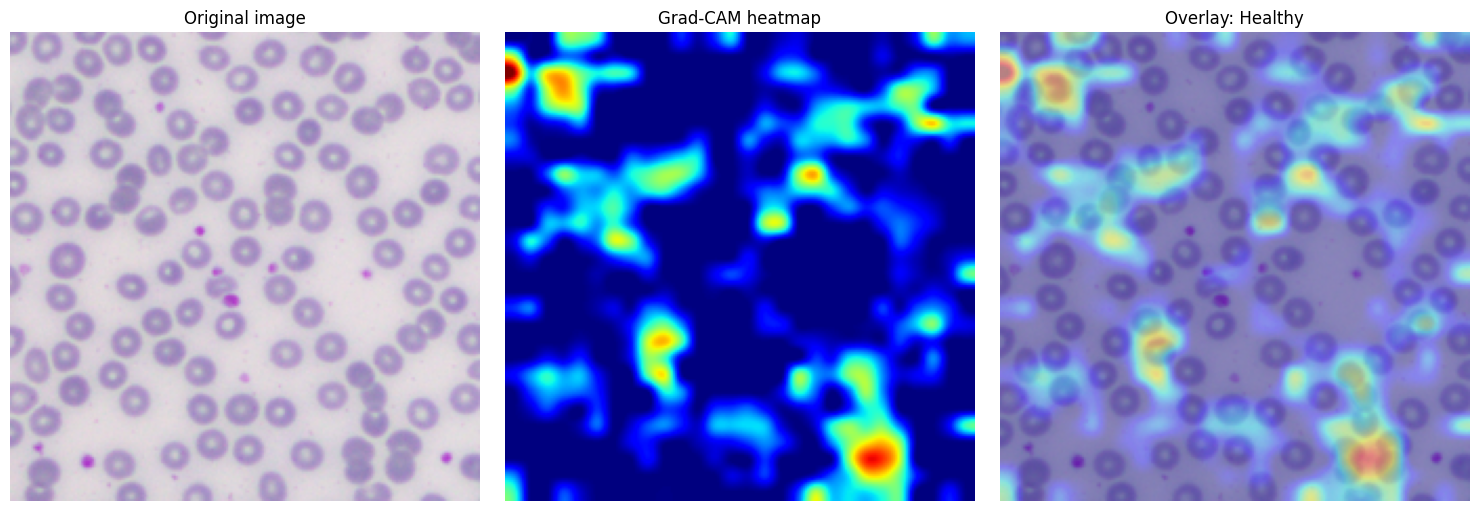

Saved Grad-CAM files:
 - /Users/kiran/Downloads/fyp/Code/newFusionModel/multiClassImageClassification/artifacts/transformed_aneRBC_ii/explainability/vgg16/sample_original_image.png
 - /Users/kiran/Downloads/fyp/Code/newFusionModel/multiClassImageClassification/artifacts/transformed_aneRBC_ii/explainability/vgg16/gradcam_heatmap.png
 - /Users/kiran/Downloads/fyp/Code/newFusionModel/multiClassImageClassification/artifacts/transformed_aneRBC_ii/explainability/vgg16/gradcam_overlay.png
 - /Users/kiran/Downloads/fyp/Code/newFusionModel/multiClassImageClassification/artifacts/transformed_aneRBC_ii/explainability/vgg16/gradcam_original_overlay_comparison.png


In [19]:
original_path = EXPLANATION_OUTPUT_DIR / "sample_original_image.png"
heatmap_path = EXPLANATION_OUTPUT_DIR / "gradcam_heatmap.png"
overlay_path = EXPLANATION_OUTPUT_DIR / "gradcam_overlay.png"
comparison_path = EXPLANATION_OUTPUT_DIR / "gradcam_original_overlay_comparison.png"

plt.imsave(original_path, np.clip(sample_image, 0, 255).astype(np.uint8))
plt.imsave(heatmap_path, resized_heatmap, cmap="jet")
plt.imsave(overlay_path, overlay_image)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(np.clip(sample_image, 0, 255).astype(np.uint8))
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(resized_heatmap, cmap="jet")
axes[1].set_title("Grad-CAM heatmap")
axes[1].axis("off")

axes[2].imshow(overlay_image)
axes[2].set_title(f"Overlay: {class_name(gradcam_class_index)}")
axes[2].axis("off")

fig.tight_layout()
fig.savefig(comparison_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved Grad-CAM files:")
for path in [original_path, heatmap_path, overlay_path, comparison_path]:
    print(" -", path)

## 8. SHAP For The CBC Branch

For a fusion model, this SHAP analysis explains only the CBC branch by holding the selected image fixed and varying CBC features. This isolates how tabular report values change the model probabilities for that fixed image context.

The notebook uses SHAP `GradientExplainer` on a CBC-only explanation model. The selected image is run through VGG16 once, its image embedding is kept fixed, and SHAP is computed through the dense CBC/fusion head. This avoids `KernelExplainer` and the repeated VGG16 calls that can make model-agnostic SHAP hang or hit ill-conditioned `_kernel.py` solves.

If the loaded model is image-only, this section is skipped with a clear message.


In [20]:
SHAP_BACKGROUND_SIZE = 50
SHAP_EXPLAIN_ROWS = 25
SHAP_GRADIENT_NSAMPLES = 100


def select_shap_values_for_class(raw_shap_values, class_index: int) -> np.ndarray:
    if isinstance(raw_shap_values, list):
        return np.asarray(raw_shap_values[class_index])

    values = np.asarray(raw_shap_values)
    if values.ndim == 2:
        return values
    if values.ndim == 3:
        if values.shape[-1] == NUM_CLASSES:
            return values[:, :, class_index]
        if values.shape[0] == NUM_CLASSES:
            return values[class_index]
    raise ValueError(f"Unexpected SHAP value shape: {values.shape}")


def select_expected_values_for_class(raw_expected_value, class_index: int, rows: int) -> np.ndarray:
    expected = np.asarray(raw_expected_value)
    if expected.ndim == 0:
        return np.full(rows, float(expected))
    if expected.ndim == 1:
        if expected.shape[0] == NUM_CLASSES:
            return np.full(rows, float(expected[class_index]))
        if expected.shape[0] == rows:
            return expected.astype(float)
    if expected.ndim == 2:
        if expected.shape[-1] == NUM_CLASSES:
            return expected[:, class_index].astype(float)
        if expected.shape[0] == NUM_CLASSES:
            return expected[class_index].astype(float)
    raise ValueError(f"Unexpected SHAP expected value shape: {expected.shape}")


def require_layer(loaded_model: tf.keras.Model, layer_name: str) -> tf.keras.layers.Layer:
    layer = get_layer_or_none(loaded_model, layer_name)
    if layer is None:
        raise ValueError(f"Required layer is missing from the loaded model: {layer_name}")
    return layer


def compute_fixed_image_embedding(loaded_model: tf.keras.Model, image_batch: np.ndarray) -> tf.Tensor:
    x = tf.convert_to_tensor(image_batch, dtype=tf.float32)
    preprocess_layer = get_layer_or_none(loaded_model, f"{MODEL_SLUG}_preprocess")
    if preprocess_layer is not None:
        x = call_layer_inference(preprocess_layer, x)
    x = call_layer_inference(require_layer(loaded_model, BASE_LAYER_NAME), x)
    for layer_name in ["image_global_average_pooling", "image_embedding_dense", "image_embedding_dropout"]:
        x = call_layer_inference(require_layer(loaded_model, layer_name), x)
    return tf.constant(x.numpy(), dtype=tf.float32)


def make_cbc_explanation_model(loaded_model: tf.keras.Model, image_batch: np.ndarray) -> tf.keras.Model:
    fixed_image_embedding = compute_fixed_image_embedding(loaded_model, image_batch)
    cbc_input = tf.keras.Input(shape=(len(CBC_FEATURES),), dtype=tf.float32, name="cbc_explanation_input")
    image_embedding = tf.keras.layers.Lambda(
        lambda cbc: tf.tile(fixed_image_embedding, [tf.shape(cbc)[0], 1]),
        name="fixed_image_embedding",
    )(cbc_input)

    y = cbc_input
    for layer_name in ["cbc_normalization", "cbc_dense_64", "cbc_dropout_64", "cbc_dense_32", "cbc_dropout_32"]:
        y = call_layer_inference(require_layer(loaded_model, layer_name), y)

    z = call_layer_inference(require_layer(loaded_model, "fusion_concat"), [image_embedding, y])
    for layer_name in ["fusion_dense_128", "fusion_dropout_128", "fusion_dense_64", "fusion_dropout_64", "classifier"]:
        z = call_layer_inference(require_layer(loaded_model, layer_name), z)

    return tf.keras.Model(cbc_input, z, name="cbc_fixed_image_explanation_model")


if not HAS_CBC_INPUT:
    print("SHAP skipped: the loaded model has no CBC/tabular input branch.")
elif not SHAP_AVAILABLE:
    print("SHAP skipped: the shap package is unavailable in this environment.")
else:
    background_df = train_df[CBC_FEATURES].sample(
        n=min(SHAP_BACKGROUND_SIZE, len(train_df)),
        random_state=SEED,
    ).reset_index(drop=True)
    explain_df = test_df[CBC_FEATURES].head(min(SHAP_EXPLAIN_ROWS, len(test_df))).reset_index(drop=True)

    background_values = background_df.to_numpy(dtype=np.float32)
    explain_values = explain_df.to_numpy(dtype=np.float32)

    cbc_explanation_model = make_cbc_explanation_model(model, sample_image_batch)
    background_predictions = cbc_explanation_model(background_values, training=False).numpy()

    shap_explainer = shap.GradientExplainer(cbc_explanation_model, background_values)
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="The structure of `inputs` doesn't match the expected structure.*",
            category=UserWarning,
        )
        raw_shap_values = shap_explainer.shap_values(explain_values, nsamples=SHAP_GRADIENT_NSAMPLES)

    shap_class_index = predicted_class_index
    class_shap_values = select_shap_values_for_class(raw_shap_values, shap_class_index)
    expected_values = select_expected_values_for_class(
        np.mean(background_predictions, axis=0),
        shap_class_index,
        len(explain_df),
    )
    expected_value = float(np.mean(expected_values))

    shap_values_path = EXPLANATION_OUTPUT_DIR / "shap_cbc_values_predicted_class.csv"
    pd.DataFrame(class_shap_values, columns=CBC_FEATURES).to_csv(shap_values_path, index=False)

    print("SHAP explainer:", type(shap_explainer).__name__)
    print("SHAP target class:", shap_class_index, class_name(shap_class_index))
    print("SHAP gradient samples:", SHAP_GRADIENT_NSAMPLES)
    print("SHAP expected value for class:", f"{expected_value:.6f}")
    print("SHAP values shape:", class_shap_values.shape)
    print("Saved SHAP values:", shap_values_path)


SHAP explainer: GradientExplainer
SHAP target class: 0 Healthy
SHAP gradient samples: 100
SHAP expected value for class: 0.916838
SHAP values shape: (25, 10)
Saved SHAP values: /Users/kiran/Downloads/fyp/Code/newFusionModel/multiClassImageClassification/artifacts/transformed_aneRBC_ii/explainability/vgg16/shap_cbc_values_predicted_class.csv


/var/folders/z7/0w2cgd0d4qz_wjt87_6t761c0000gn/T/ipykernel_76978/3630209689.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


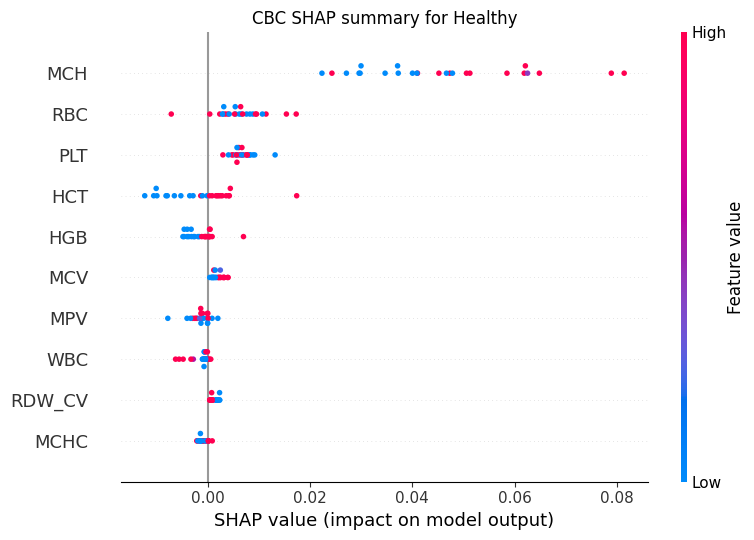

/var/folders/z7/0w2cgd0d4qz_wjt87_6t761c0000gn/T/ipykernel_76978/3630209689.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


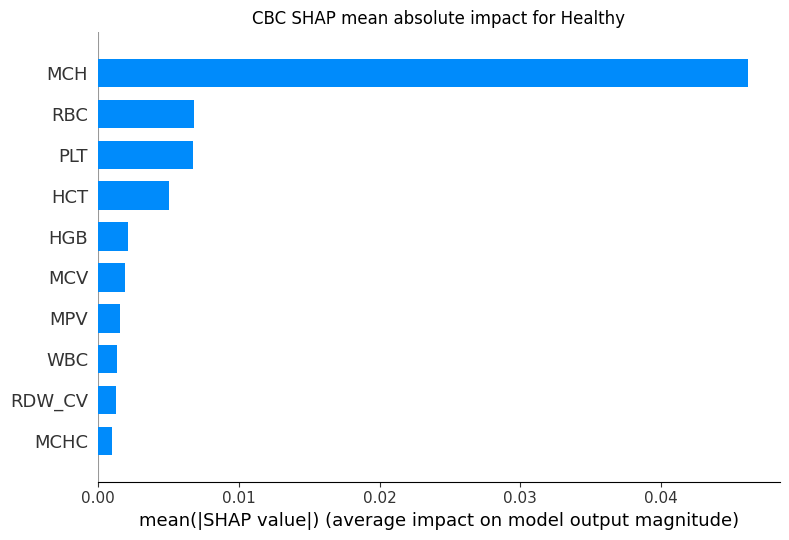

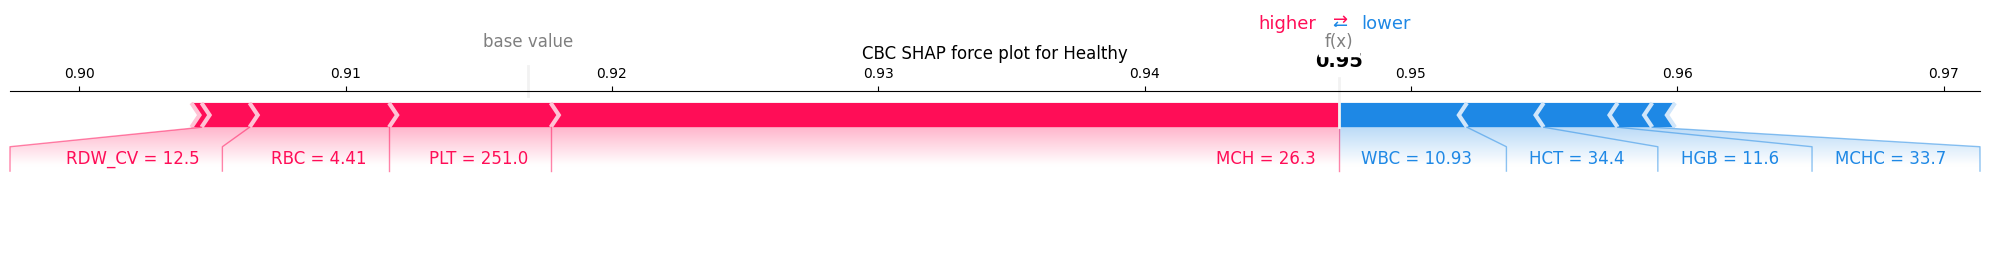

Saved SHAP plot files:
 - /Users/kiran/Downloads/fyp/Code/newFusionModel/multiClassImageClassification/artifacts/transformed_aneRBC_ii/explainability/vgg16/shap_cbc_summary_predicted_class.png
 - /Users/kiran/Downloads/fyp/Code/newFusionModel/multiClassImageClassification/artifacts/transformed_aneRBC_ii/explainability/vgg16/shap_cbc_bar_predicted_class.png
 - /Users/kiran/Downloads/fyp/Code/newFusionModel/multiClassImageClassification/artifacts/transformed_aneRBC_ii/explainability/vgg16/shap_cbc_force_predicted_class.png


In [21]:
if not HAS_CBC_INPUT or not SHAP_AVAILABLE:
    print("SHAP plots skipped.")
else:
    shap_summary_path = EXPLANATION_OUTPUT_DIR / "shap_cbc_summary_predicted_class.png"
    shap_bar_path = EXPLANATION_OUTPUT_DIR / "shap_cbc_bar_predicted_class.png"
    shap_force_path = EXPLANATION_OUTPUT_DIR / "shap_cbc_force_predicted_class.png"

    plt.figure(figsize=(9, 6))
    shap.summary_plot(
        class_shap_values,
        explain_df,
        feature_names=CBC_FEATURES,
        show=False,
        max_display=len(CBC_FEATURES),
    )
    plt.title(f"CBC SHAP summary for {class_name(shap_class_index)}")
    plt.tight_layout()
    plt.savefig(shap_summary_path, dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    shap.summary_plot(
        class_shap_values,
        explain_df,
        feature_names=CBC_FEATURES,
        plot_type="bar",
        show=False,
        max_display=len(CBC_FEATURES),
    )
    plt.title(f"CBC SHAP mean absolute impact for {class_name(shap_class_index)}")
    plt.tight_layout()
    plt.savefig(shap_bar_path, dpi=150, bbox_inches="tight")
    plt.show()

    try:
        force_expected_value = float(expected_values[0]) if "expected_values" in globals() else expected_value
        shap.force_plot(
            force_expected_value,
            class_shap_values[0],
            explain_df.iloc[0],
            feature_names=CBC_FEATURES,
            matplotlib=True,
            show=False,
        )
        plt.title(f"CBC SHAP force plot for {class_name(shap_class_index)}")
        plt.tight_layout()
        plt.savefig(shap_force_path, dpi=150, bbox_inches="tight")
        plt.show()
    except Exception as exc:
        print(f"Matplotlib force plot failed, but SHAP summary and bar plots were saved: {exc}")
        shap_force_path = None

    print("Saved SHAP plot files:")
    for path in [shap_summary_path, shap_bar_path, shap_force_path]:
        if path is not None:
            print(" -", path)


## 9. Output Files

The explainability artifacts (Grad-CAM and optional SHAP plots) are saved under the output directory printed below.

In [22]:
print("Explanation output directory:", EXPLANATION_OUTPUT_DIR)
print("Files currently present:")
for path in sorted(EXPLANATION_OUTPUT_DIR.glob("*")):
    if path.is_file():
        print(" -", path.name)

Explanation output directory: /Users/kiran/Downloads/fyp/Code/newFusionModel/multiClassImageClassification/artifacts/transformed_aneRBC_ii/explainability/vgg16
Files currently present:
 - gradcam_heatmap.png
 - gradcam_original_overlay_comparison.png
 - gradcam_overlay.png
 - sample_original_image.png
 - shap_cbc_bar_predicted_class.png
 - shap_cbc_force_predicted_class.png
 - shap_cbc_summary_predicted_class.png
 - shap_cbc_values_predicted_class.csv
